# Logistic Regression Manual Implementation

- Pedro Mauri Mtz - A01029143

## Imports

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "../"))

## Load Data

In [14]:
x = []
y = []

with open(os.path.join(ROOT, "Datasets/ex2data2.txt"), "r") as file:
    for line in file:
        col1, col2, col3 = line.split(",")        
        x.append([float(col1), float(col2)])
        y.append(int(col3))

x = np.array(x)
y = np.array(y)

## Initial Values

In [15]:
alpha = 0.1
iteraciones = 5000
lambda_ = 1

## Functions

In [16]:
def graficaDatos(x, y, theta):

    # Separar puntos positivos y negativos
    positivos = x[y == 1]
    negativos = x[y == 0]
    # Graficar puntos
    plt.scatter(positivos[:, 0], positivos[:, 1], c='b', marker='+', label='Puntos aceptados (y=1)')
    plt.scatter(negativos[:, 0], negativos[:, 1], c='r', marker='o', label='Puntos rechazados (y=0)')
    
    # Trazar línea de regresión logistica:
    if theta.size > 0:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)

        U, V = np.meshgrid(u, v)

        # Evalúa toda la malla de una sola vez
        Z = sigmoidal(mapeoCaracteristicas(np.c_[U.ravel(), V.ravel()]) @ theta).reshape(U.shape)

        plt.contour(U, V, Z, levels=[0.5], colors='g')

        plt.plot([], [], color='g', label='Frontera de decisión')
    
    # Configuración:
    plt.title('Proyecto 2 - Regresión logística')
    plt.legend()
    plt.xlabel('Eje x')
    plt.ylabel('Eje y')
    plt.grid(True)
    # Graficar
    plt.show()

## Logistic Regression Implementation

In [17]:
def mapeoCaracteristicas(x):
    grado = 6

    x1 = x[:, 0]
    x2 = x[:, 1]

    mapeado = [np.ones(x.shape[0])]

    for i in range(1, grado + 1):
        for j in range(i + 1):
            term = (x1 ** (i - j)) * (x2 ** j)
            mapeado.append(term)

    return np.stack(mapeado, axis=1)

In [18]:
def sigmoidal(z):
    return 1 / (1 + np.exp(-z))

In [19]:
def calculaCostoReg(theta, x, y, lambda_):
    m = len(y)

    theta = theta.reshape(-1, 1)
    y = y.reshape(-1, 1)

    h = sigmoidal(x @ theta)

    # Costo
    costo = (-1/m) * (y.T @ np.log(h) + (1-y).T @ np.log(1-h))
    reg = (lambda_/(2*m)) * np.sum(theta[1:]**2)  # sin theta0
    J = costo + reg

    # Gradiente
    error = h - y
    grad = (1/m) * (x.T @ error)
    grad[1:] = grad[1:] + (lambda_/m)*theta[1:]

    return J.item(), grad.flatten()

In [20]:
def train(x, y, theta, alpha, iteraciones, lambda_):
    J_hist = []

    for i in range(iteraciones):
        J, grad = calculaCostoReg(theta, x, y, lambda_)
        theta = theta - alpha * grad
        J_hist.append(J)

        if (i+1) % 500 == 0 or i == 0:
            print(f"Iteración {i+1}: Costo={J:.4f}")

    return theta, J_hist

In [21]:
def test(theta, x):
    h = sigmoidal(x @ theta)

    predicciones = np.where(h >= 0.5, 1, 0)

    return predicciones

## Running Logistic Regression

In [22]:
X_mapped = mapeoCaracteristicas(x)
theta = np.zeros(X_mapped.shape[1])
theta = np.array(theta)

# Training
theta, J_hist = train(X_mapped, y, theta, alpha, iteraciones, lambda_)


Iteración 1: Costo=0.6931
Iteración 500: Costo=0.5535
Iteración 1000: Costo=0.5344
Iteración 1500: Costo=0.5304
Iteración 2000: Costo=0.5294
Iteración 2500: Costo=0.5291
Iteración 3000: Costo=0.5290
Iteración 3500: Costo=0.5290
Iteración 4000: Costo=0.5290
Iteración 4500: Costo=0.5290
Iteración 5000: Costo=0.5290


## Results

In [23]:
predicciones = test(theta, X_mapped)
precision = np.mean(predicciones == y) * 100
print(f"Precisión de entrenamiento: {precision:.4f}%")

Precisión de entrenamiento: 83.0508%


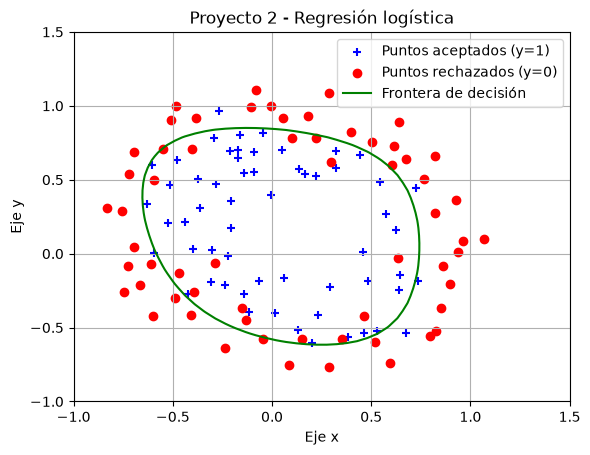

In [24]:
graficaDatos(x, y, theta)

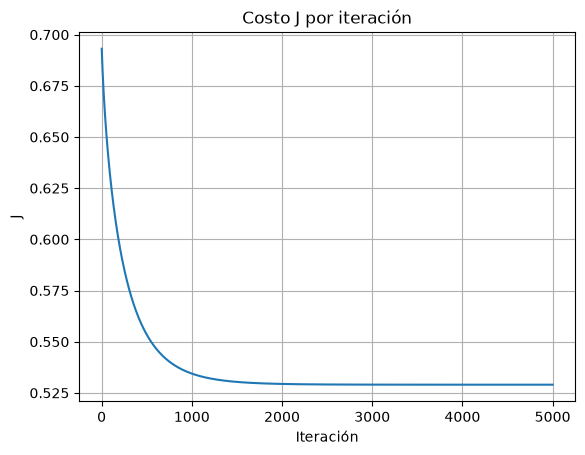

In [25]:
plt.plot(range(1, len(J_hist) + 1), J_hist)
plt.title('Costo J por iteración')
plt.xlabel('Iteración')
plt.ylabel('J')
plt.grid(True)
plt.show()